# Introduction to Pytorch and MLP
In this notebook we will learn how to implement and train a neural network using the [pytorch](https://pytorch.org/) library.

## Introduction to Pytorch

[Pytorch](https://pytorch.org/) is a ML library to implement and train neural networks. It uses automatic differation to automatically compute the gradient of a function which makes it very convenient to train large neural networks.

### Tensors

In pytorch we use [tensors](https://pytorch.org/docs/stable/tensors.html) to represent variables. They are used to store data or for computation.

In [2]:
import torch
x = torch.tensor([[0,1], [2,3]])
print(x)

tensor([[0, 1],
        [2, 3]])


Tensors supports most math operations:

In [8]:
a = torch.tensor([[0,1], [2,3]])
b = torch.tensor([[4,5], [6,7]])

print(a + b)
print(a * b) # The * operator corresponds to element-wise multiplication
print(a.mm(b)) # To compute a matrix product use the mm() method instead

tensor([[ 4,  6],
        [ 8, 10]])
tensor([[ 0,  5],
        [12, 21]])
tensor([[ 6,  7],
        [26, 31]])


#### Exercise:
Implement the following function that takes two tensor as input and outputs:
$$f(x, y) = \|x\|_2^2 + \|y\|_2^2 - 2\sum_i x_iy_i$$

where $\|x\|_2 = \sqrt{\sum_i x_i^2}$ is the L2-norm of tensor $x$.

In [3]:
def f(x, y):
  # Implement your solution here

  result = torch.sum(x*x) + torch.sum(y*y) - 2 * torch.sum(x*y)
  return result

assert f(torch.tensor([[0,1], [2,3]]), torch.tensor([[4,5], [6,7]])).item() == 64

##### Hint:

You can use the `torch.sum()` method to compute the sum of all the elements of a tensor.

##### Solution:

In [ ]:
def f(x, y):
  z = torch.sum(x**2) + torch.sum(y**2) - 2*torch.sum(x*y)
  # z = torch.sum((x-y)**2) # This simplified alternative also works.
  return z

assert f(torch.tensor([[0,1], [2,3]]), torch.tensor([[4,5], [6,7]])).item() == 64

### Automatic differentiation

Pytorch can compute the gradient of a tensor with respect to other tensors by using the `backward()` method:

In [4]:
from torch.autograd import grad

x = torch.ones(5)  # input tensor
y = torch.zeros(3)  # expected output
w = torch.randn(5, 3, requires_grad=True) # By specifying requires_grad=True we tell pytorch
b = torch.randn(3, requires_grad=True)    # that we want those tensors to be differentiable.
z = torch.matmul(x, w) + b #bias is something you're trying to learn
loss = torch.sum((z - y)**2) #y is your labels
loss.backward() # The backward() method will compute the gradient of this tensor.

print(b.grad) # The results is stored in the grad attribute of the tensor.
print(w.grad)
print(x.grad) # The gradient is None for tensors without requires_grad=True

tensor([-6.6824, -6.6576, -7.6652])
tensor([[-6.6824, -6.6576, -7.6652],
        [-6.6824, -6.6576, -7.6652],
        [-6.6824, -6.6576, -7.6652],
        [-6.6824, -6.6576, -7.6652],
        [-6.6824, -6.6576, -7.6652]])
None


#### Exercise:
Write a function that computes the following function:

$$g(x, y) = \frac{\partial f(x,y)}{\partial x}y + \frac{\partial f(x,y)}{\partial y}x$$

where is the function defined in the previous exercise.


In [9]:
def f(x, y):
  z = torch.sum((x-y)**2)
  return z

def g(x, y):
  # Write your code below
  z = f(x,y)
  z.backward()
  result = x.grad*y + y.grad*x
  return result


x = torch.tensor([[0,1], [2,3]], dtype=torch.float32, requires_grad=True)
y = torch.tensor([[4,5], [6,7]], dtype=torch.float32, requires_grad=True)
assert torch.all(g(x,y) == -2*(x -y)**2)

##### Solution:

In [ ]:
def f(x, y):
  z = torch.sum((x-y)**2)
  return z

def g(x, y):
  z = f(x,y)
  z.backward()
  return x.grad*y + y.grad*x


x = torch.tensor([[0,1], [2,3]], dtype=torch.float32, requires_grad=True)
y = torch.tensor([[4,5], [6,7]], dtype=torch.float32, requires_grad=True)
assert torch.all(g(x,y) == -2*(x -y)**2)

### GPU and Cuda
Computation can be done either on CPU or GPU. Training large neural networks is usually done on GPUs, taking advantage of parallelization to train faster.

Using a GPU requires moving all the tensors on the GPU. By default all the tensors are on the CPU.
To move a tensor to the GPU you can use either the `cuda()` or the `to("cuda")` method.

Before moving your device to a GPU first change your runtime:
- Go to Runtime -> Change runtime type
- Select GPU in the hardware selector
- Click the save button
You're now ready to use the GPU !

In [11]:
import torch

x = torch.ones(5).cuda()
y = torch.zeros(5).to("cuda")
z = torch.zeros(5).cuda()

print(x + y) # Tensor need to be on the same device
print(x + z) # Raise an error because the tensors are not on the same device.

tensor([1., 1., 1., 1., 1.], device='cuda:0')
tensor([1., 1., 1., 1., 1.], device='cuda:0')


## Implementing and training a neural network (NN) using pytorch
Now that we've covered the basics of pytorch, we will explore how we can use pytorch to implement and train a neural networks from scratch to recognize images of digits using the [MNIST](https://pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html) dataset.

### Loading the dataset
We start by loading the MNIST dataset. Luckily it's already available in pytorch by using the [torchvision](https://pytorch.org/vision/stable/index.html) package.

In [ ]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms

# We can use transform to apply transformation to the dataset
transform = transforms.ToTensor() # Here we simply make sure that the images are transformed into Tensors

# We load both the training set and the test set. The data we'll be directly downloaded and stored in the data folder
train_dataset = MNIST(root='../data',
                      train=True,
                      transform=transform,
                      download=True)

test_dataset = MNIST(root='../data',
                     train=False,
                     transform=transform)

100%|██████████| 9912422/9912422 [00:00<00:00, 207833871.94it/s]

Extracting ../data/MNIST/raw/train-images-idx3-ubyte.gz to ../data/MNIST/raw


100%|██████████| 28881/28881 [00:00<00:00, 17932745.20it/s]


Extracting ../data/MNIST/raw/train-labels-idx1-ubyte.gz to ../data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 66531581.80it/s]

Extracting ../data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 23519171.32it/s]


Extracting ../data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/MNIST/raw



Let's explore the characteristic of the dataset:

The training set has 60000 images of size torch.Size([1, 28, 28])
The label of this image is: 5


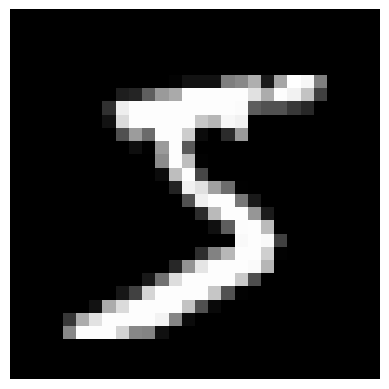

In [ ]:
import matplotlib.pyplot as plt

train_data = iter(train_dataset)
image, label = next(train_data)
print(f"The training set has {len(train_dataset)} images of size {image.size()}")
print(f"The label of this image is: {label}")
plt.imshow(image.squeeze(), cmap="gray")
plt.axis('off')
plt.show()

#### Using dataloaders to load the data in parallel.
Reading the data from disk can be quite slow. Pytorch uses dataloader to load several images at once in parallel.

In [ ]:
from torch.utils.data import DataLoader

batch_size = 128  # The batch-size is a hyperparameter that defines the number of images processed in parallel by the NN.
                 # Choosing a batch-size too small will result in a slow training
                 # Choosing a batch-size too large will result in out-of-memory error
train_loader = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle = True)

test_loader = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = False)

### Implementing the neural network
To implement neural network, pytorch uses [Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html).

In [ ]:
from torch import nn
import torch.nn.functional as F

class NeuralNetwork(nn.Module):
  # Your neural network should inherit from the `Module` base class.

  def __init__(self):
    super().__init__()

    # We define the "structure" of the neural network in the `init` funtion.

    self.hidden_layer = nn.Linear(784, 100) # Here 784 is the input size to the layer and 100 is the output size.
                                            # Because this layer is a "hidden layer" the output size of the layer,
                                            # is also called the "hidden size" of the layer
    self.output_layer = nn.Linear(100, 10)  # The input size of a layer must be the same as the output size from the previous layer.
                                            # Here the second layer is the last layer so the output size will be the number of class we need to predict.
                                            # In our example we want to predict digits so it will be 10.

  def forward(self, x):
    # We always need to implement the forward method.
    # This indicates how to compute the output of the neural network from the input
    batch_size = len(x)
    x = x.view(batch_size, 784)            # We need to reshape the input to match the input size of the first layer.
    hidden = self.hidden_layer(x)          # Input size: (batch_size, 784) -> Output size: (batch_size, 100)
    activation = F.relu(hidden)            # We apply non-linear transformation to the ouput of hidden layers.
                                           # A common non-linear activation is the relu function.
    output = self.output_layer(activation) # Input size: (batch_size, 100) -> Output size: (batch_size, 10)
    return output

model = NeuralNetwork()
output = model(image)        # The model outputs a vector that assign a score to each class.
prediction = output.argmax() # To get the prediction of the model we select the elemnt with the highest score
print(f"Output of the model: {output}")
print(f"The model predicted: {prediction} but the real label is {label}")

Output of the model: tensor([[ 0.0348, -0.0046, -0.0267, -0.0196,  0.1727, -0.0527,  0.0433, -0.0550,
         -0.0302, -0.0330]], grad_fn=<AddmmBackward0>)
The model predicted: 4 but the real label is 5


#### Exercise:
1. Write a neural network with two hidden layers, the first one with a hidden size of 200, the second one with a hidden size of 50.
2. Update your class so that the hidden size for each layers can be passed as a parameter to the class.

In [ ]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    # Write your code here


  def forward(self, x):
    # Write your code here

    return output

model = NeuralNetwork([200, 50])
output = model(image)        # The model outputs a vector that assign a score to each class.
prediction = output.argmax() # To get the prediction of the model we select the elemnt with the highest score
print(f"Output of the model: {output}")
print(f"The model predicted: {prediction} but the real label is {label}")

##### Solution:

In [ ]:
class NeuralNetwork(nn.Module):
  def __init__(self, hidden_sizes):
    super().__init__()

    input_size = 784
    self.hidden_layers = nn.ModuleList()
    for hidden_size in hidden_sizes:
      hidden_layer = nn.Linear(input_size, hidden_size)
      self.hidden_layers.append(hidden_layer)
      input_size = hidden_size

    self.output_layer = nn.Linear(input_size, 10)

  def forward(self, x):
    batch_size = len(x)
    x = x.view(batch_size, 784)

    for layer in self.hidden_layers:
      h = layer(x)
      x = F.relu(h)

    output = self.output_layer(x)

    return output

model = NeuralNetwork([200, 50])
output = model(image)        # The model outputs a vector that assign a score to each class.
prediction = output.argmax() # To get the prediction of the model we select the elemnt with the highest score
print(f"Output of the model: {output}")
print(f"The model predicted: {prediction} but the real label is {label}")

Output of the model: tensor([[ 0.1366,  0.0798,  0.0719, -0.2248, -0.0609, -0.0249,  0.0201,  0.1547,
          0.1207, -0.0376]], grad_fn=<AddmmBackward0>)
The model predicted: 7 but the real label is 5


### Writting the evaluation function
The evaluation function computes the accuracy of the model on the testset.

In [ ]:
import tqdm

def accuracy(outputs, labels):
  predictions = outputs.argmax(-1)
  correct = torch.sum(labels == predictions).item()
  return correct / len(labels)

def evaluate(loader, model, device="cpu"):
  acc = 0
  loss = 0
  n_samples = 0

  model = model.to(device)
  model.eval() # Some neural networks can behave differently between training and evaluation.
               # By using `eval` we make sure the model is in evaluation mode.

  # We iterate over all the testset, loading one batch of images at a time and computing the accuracy for the batch.
  for images, labels in tqdm.tqdm(loader):
    with torch.no_grad(): # When evaluating the model we don't need to compute the gradients,
                          # so we can disable it using `no_grad()`.
      # Move the tensor to appropriate device
      images = images.to(device)
      labels = labels.to(device)

      # Compute the outputs of the model
      outputs = model(images)

      # Compute the loss
      loss += loss_function(outputs, labels).item()*len(labels)

      # Compute the accuracy
      acc += accuracy(outputs, labels)*len(labels)
      n_samples += len(labels)

  return loss / n_samples, acc / n_samples

### The training loop
The training loop is the most important part of the code. It defines how we train the model and update the parameters of the model.

In [ ]:
def train(loader, model, optimizer, device="cpu"):
  train_loss = 0
  train_acc = 0
  n_samples = 0

  model = model.to(device)
  model.train() # Some neural networks can behave differently between training and evaluation.
               # By using `train` we make sure the model is in training mode.

  # We iterate over the trainset, loading one batch of images at a time, computing the loss of the model,
  # and updating the parameters of the model using stochastic gradient descent.
  for images, labels in tqdm.tqdm(loader):
    optimizer.zero_grad() # We make sure that the grad attribute of all the tensors in the graph are reset to 0.

    # Move the tensor to the appropriate device
    images = images.to(device)
    labels = labels.to(device)

    # Compute the outputs of the model
    outputs = model(images)

    # Compute the loss
    loss = loss_function(outputs, labels)

    # Compute the gradients
    loss.backward()


    # Update the parameters of the model
    optimizer.step()

    train_loss += loss.detach().item()*len(labels)
    train_acc += accuracy(outputs, labels)*len(labels)
    n_samples += len(labels)

  return train_loss / n_samples, train_acc / n_samples

### Training the model
Now we have all the blocks to finally train the model.

In [ ]:
from torch import optim

device = "cuda" if torch.cuda.is_available() else "cpu" # If a GPU is available we use the GPU to accelerate training.

# We start by initializing the model
model = NeuralNetwork([100])

# We define the objective function we want to use
loss_function = nn.CrossEntropyLoss() # For multiclass classification a popular choice for the objective function is the cross-entropy loss.

# We define the optimizer we want to use
lr = 1e-2 # The learning rate is a hyperparameter.
optimizer = optim.SGD(model.parameters(), lr=lr) # Here we're going to use stochastic gradient descent (SGD).

train_losses = []
test_losses = []
train_accuracy = []
test_accuracy = []

num_epochs = 10 # The number of epochs is a hyperparameter. The largest the number of epochs the longer we will train the neural network.

for epoch in range(num_epochs):
  train_loss, train_acc = train(train_loader, model, optimizer, device)
  test_loss, test_acc = evaluate(test_loader, model, device)

  train_losses.append(train_loss)
  train_accuracy.append(train_acc)
  test_losses.append(test_loss)
  test_accuracy.append(test_acc)

  print(f'Epoch: {epoch+1}/{num_epochs}, Train loss: {train_loss:.2e}, Train accuracy: {train_acc:.2%}, Test accuracy: {test_acc:.2%}')

100%|██████████| 79/79 [00:01<00:00, 40.86it/s]


Epoch: 1/10, Train loss: 1.78e+00, Train accuracy: 62.32%, Test accuracy: 79.86%


100%|██████████| 79/79 [00:01<00:00, 47.36it/s]


Epoch: 2/10, Train loss: 8.24e-01, Train accuracy: 82.75%, Test accuracy: 85.98%


100%|██████████| 79/79 [00:01<00:00, 53.26it/s]


...

Epoch: 8/10, Train loss: 3.45e-01, Train accuracy: 90.37%, Test accuracy: 91.10%


100%|██████████| 79/79 [00:01<00:00, 48.33it/s]


Epoch: 9/10, Train loss: 3.32e-01, Train accuracy: 90.74%, Test accuracy: 91.40%


100%|██████████| 79/79 [00:01<00:00, 41.13it/s]

Epoch: 10/10, Train loss: 3.21e-01, Train accuracy: 90.97%, Test accuracy: 91.59%


Let's visualize the results:

Text(0.5, 1.0, 'Error rate')

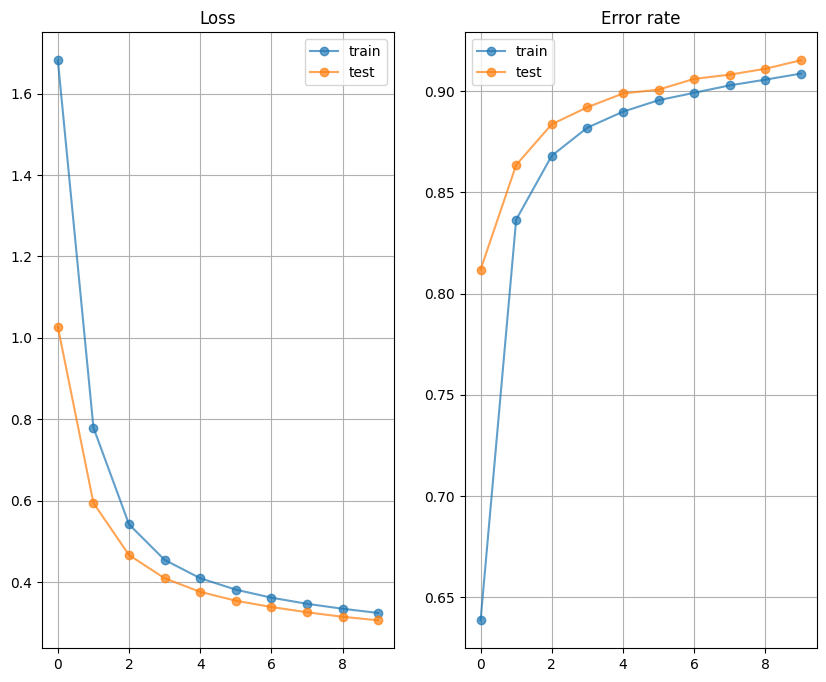

In [ ]:
plt.figure(figsize=(10, 8))
plt.subplot(1,2,1)
plt.plot(train_losses, label='train', marker='o', alpha=0.7)
plt.plot(test_losses, label='test', marker='o', alpha=0.7)
plt.grid(True)
plt.legend()
plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(train_accuracy, label='train', marker='o', alpha=0.7)
plt.plot(test_accuracy, label='test', marker='o', alpha=0.7)
plt.grid(True)
plt.legend()
plt.title('Error rate')

### Exercise:
Open this [Training Experiment Workbook](https://docs.google.com/spreadsheets/d/1waOhXsaxzwzzWNdHkBKBSyX4ALTsLOy8CJ4NVBjxIVA/edit?usp=sharing) and create a copy. Everytime you run an experiment report the hyperparameters and the results in your Training Experiment Workbook.
1. Change the learning rate, what do you observe ?
2. Change the hidden size of the hidden layer, what do you observe ?
3. Add a hidden layer to the model, what do you observe ?
4. Change the optimizer to [Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam), do you observe any improvments ?
5. Try to find the set of all hyperparameters that achieve the best test accuracy possible. Which combination of hyperparameters worked best ?
6. Discuss with the rest of the groups about your observations, and what you've learnt.

*Note: you don't have to answer all of those questions by yourself. Try to share the different questions among your group.*

## Further exercise
1. Implement and train a neural network on the [CIFAR10 dataset](https://pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html).
2. Explore different hyperparameters, optimizers, number of layers. Report all your experiments in your Training Experiment Workbook.
3. What set of hyperparameters worked best ?
4. Reflect on what you learnt. Share your findings with the rest of the group.  Example of question to ask yourself: What seemed to work well ? What didn't seem to work ? What didn't you have time to explore but you think might improve your results ? What was the most difficult part about this exercise ?